In [9]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
import pickle
from pathlib import Path
import os
from utils import *
from tqdm import tqdm

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'

# ================= MODEL & SIMULATION PARAMETERS =================
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=False
model_names = ['nm', 'dcm', 'vcm']
distortion_params = {'None': {'distortion': None, 'a': None, 'b':None},
                     'shear1': {'distortion': 'shear', 'a': 0, 'b': 0.3},
                     'stretch1': {'distortion': 'stretch', 'a': 1, 'b': 0.67}}
# =================================================================


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=None -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/nm_trials-100_undistorted.pkl


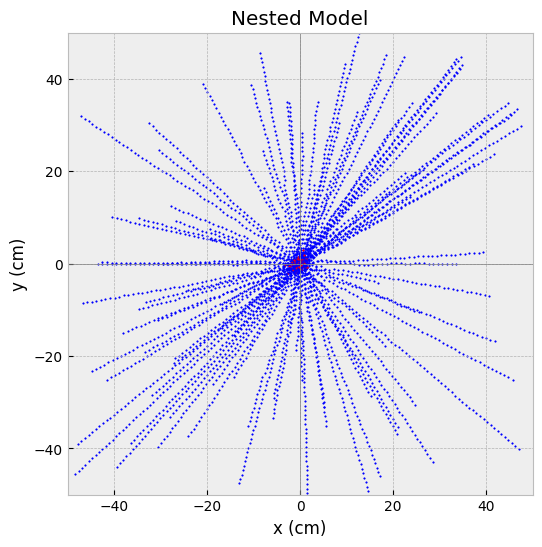

Successful trials: 100/100 (100.0%)
Mean error: 1.16, Median error: 1.00, Std error: 0.62
Loading simulation data from simulation_outputs/dcm_trials-100_undistorted.pkl


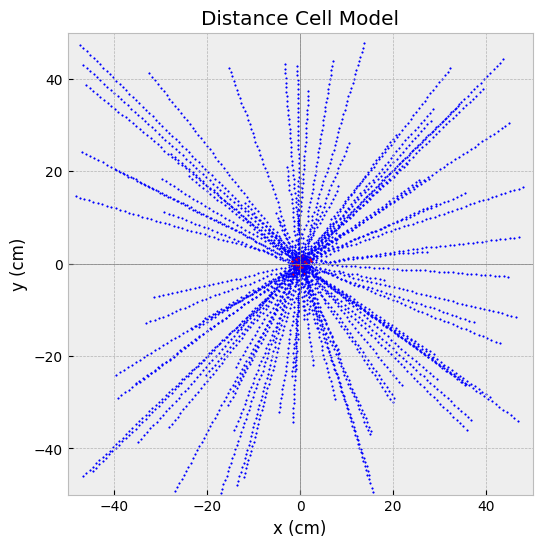

Successful trials: 100/100 (100.0%)
Mean error: 0.98, Median error: 0.91, Std error: 0.56
Loading simulation data from simulation_outputs/vcm_trials-100_undistorted.pkl


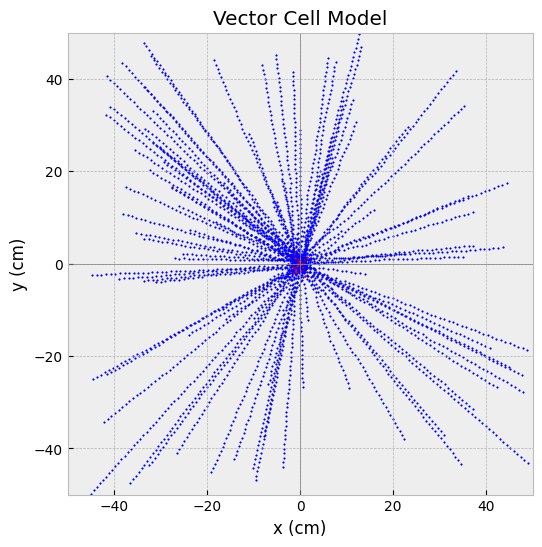

Successful trials: 100/100 (100.0%)
Mean error: 1.06, Median error: 0.94, Std error: 0.61

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/nm_trials-100_shear_a-0_b-0.3.pkl


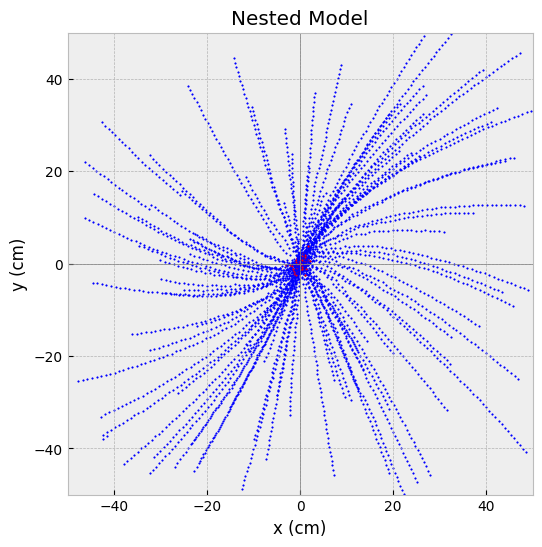

Successful trials: 100/100 (100.0%)
Mean error: 1.23, Median error: 1.10, Std error: 0.71
Loading simulation data from simulation_outputs/dcm_trials-100_shear_a-0_b-0.3.pkl


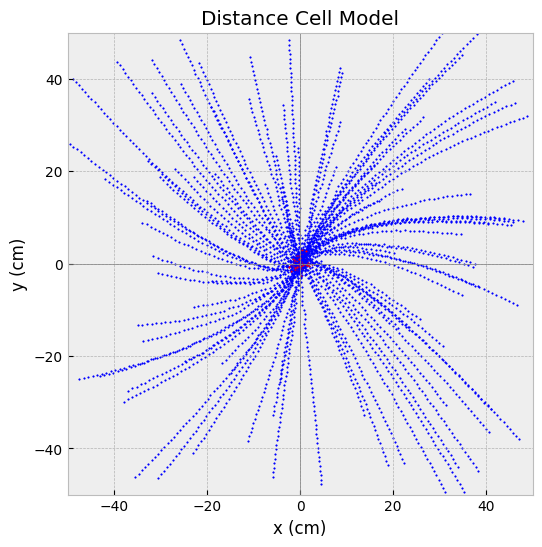

Successful trials: 100/100 (100.0%)
Mean error: 1.08, Median error: 0.94, Std error: 0.64
Loading simulation data from simulation_outputs/vcm_trials-100_shear_a-0_b-0.3.pkl


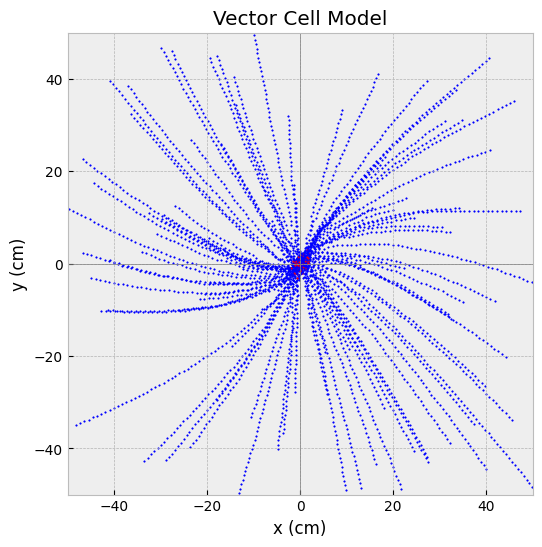

Successful trials: 100/100 (100.0%)
Mean error: 1.13, Median error: 0.95, Std error: 0.66

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=stretch1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/nm_trials-100_stretch_a-1_b-0.67.pkl


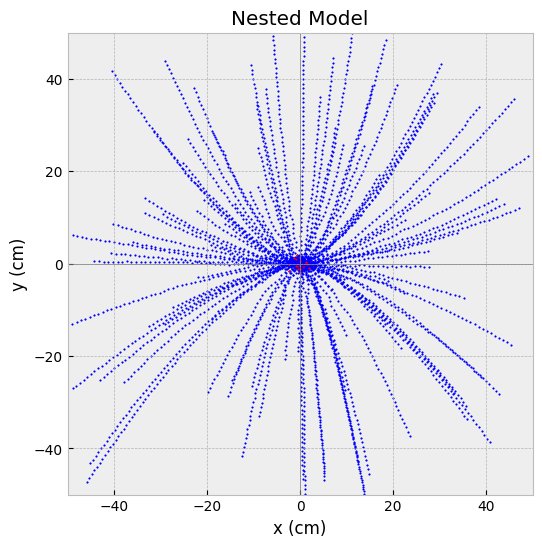

Successful trials: 100/100 (100.0%)
Mean error: 1.10, Median error: 0.96, Std error: 0.64
Loading simulation data from simulation_outputs/dcm_trials-100_stretch_a-1_b-0.67.pkl


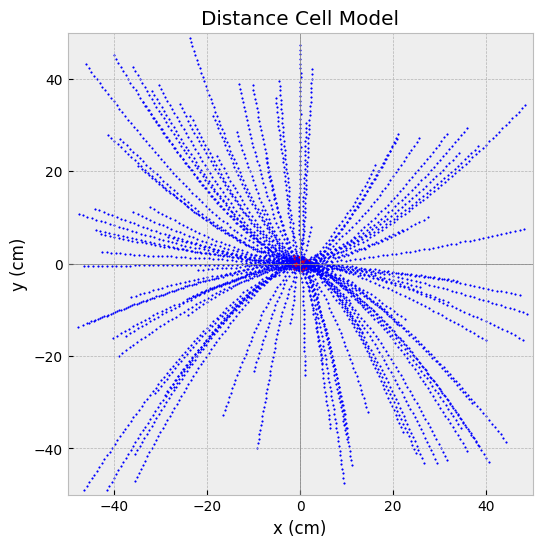

Successful trials: 100/100 (100.0%)
Mean error: 0.91, Median error: 0.78, Std error: 0.53
Loading simulation data from simulation_outputs/vcm_trials-100_stretch_a-1_b-0.67.pkl


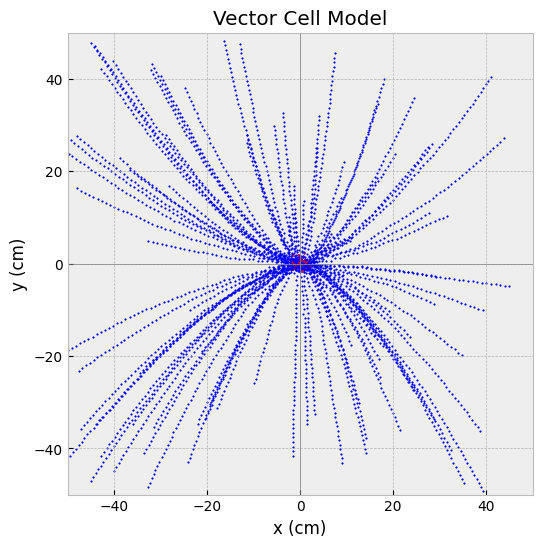

Successful trials: 100/100 (100.0%)
Mean error: 0.94, Median error: 0.87, Std error: 0.53


In [12]:
for distortion_name in distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in model_names: #['nm', 'dcm']:
        x_histories, y_histories = run_load_simulation(model_name, 
                                                    arena_width=ARENA_WIDTH, 
                                                    step_size=STEP_SIZE,
                                                    convergence_threshold=CONV_THRESH,
                                                    n_trials=N_TRIALS, 
                                                    distortion_params=distortion_params[distortion_name],
                                                    hexagonal_projection=HEX_PROJ
                                                        )
        plot_trajectories(model_name, x_histories, y_histories, hexagonal_projection=HEX_PROJ)
        plot_error(x_histories, y_histories)


In [3]:
for trial in range(len(x_histories)):

    xs = x_histories[trial]
    ys = y_histories[trial]
    pos_xy_mat = np.array([xs, ys])
 #   xs = project_onto_axis(pos_xy_mat, 1)
 #   ys = project_onto_axis(pos_xy_mat, 2)
    end_x = xs[-1]
    end_y = ys[-1]
    if end_x > 3:
        print(f'trial {trial}: ------end_x:',end_x)
        for i in range(len(xs)):
            if i < 1:
                continue
            end_x = xs[i]
            end_y = ys[i]
            old_x = xs[i-1]
            old_y = ys[i-1]
            distance_moved = np.sqrt((end_x - old_x) ** 2 + (end_y - old_y) ** 2)
            print(f'{i}: at ({end_x},{end_y}), distance_moved:', distance_moved)


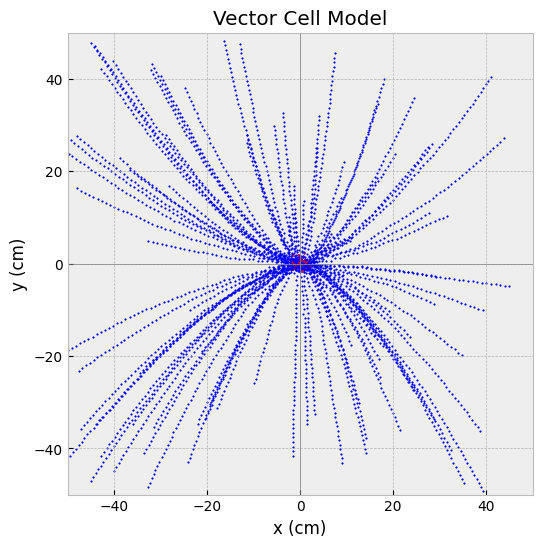

Successful trials: 100/100 (100.0%)


In [11]:
def plot_trajectories(model_name, x_histories, y_histories, arena_width = 50, hexagonal_projection=True):
    long_names = {'nm': 'Nested Model', 'dcm': 'Distance Cell Model', 'vcm': 'Vector Cell Model'}

    n_trials = len(x_histories)
    plt.figure(figsize=(6, 6))

    # Project the trajectories onto the hexagonal axes
    if hexagonal_projection:
        x_histories_proj = []
        y_histories_proj = []
        for trial in range(len(x_histories)):
            pos_xy_mat = np.array([x_histories[trial], y_histories[trial]])
            proj_X = project_onto_axis(pos_xy_mat, 1)
            proj_Y = project_onto_axis(pos_xy_mat, 2)
            x_histories_proj.append(proj_X)
            y_histories_proj.append(proj_Y)
        x_histories = x_histories_proj
        y_histories = y_histories_proj

    success_count = 0
    for trial in range(n_trials):
        last_x = x_histories[trial][-1]
        last_y = y_histories[trial][-1]
        success = np.sqrt(last_x**2 + last_y**2) <= 5
        color = 'blue' if success else 'red'
        success_count += success
        plt.scatter(x_histories[trial], y_histories[trial], color=color, s=1)
        plt.scatter(x_histories[trial][-1], y_histories[trial][-1], color='red', s=1)
        
    plt.xlim(-arena_width, arena_width)
    plt.ylim(-arena_width, arena_width)
  #plt.xticks([])
  #  plt.yticks([])
 #   plt.xlim(-5,5)
 #   plt.ylim(-5,5)
    plt.title(f'{long_names[model_name]}')
    plt.xlabel('x (cm)')
    plt.ylabel('y (cm)')
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)

    plt.show()
    print(f'Successful trials: {success_count}/{n_trials} ({(success_count/n_trials)*100:.1f}%)')
plot_trajectories(model_name, x_histories, y_histories, hexagonal_projection=False)

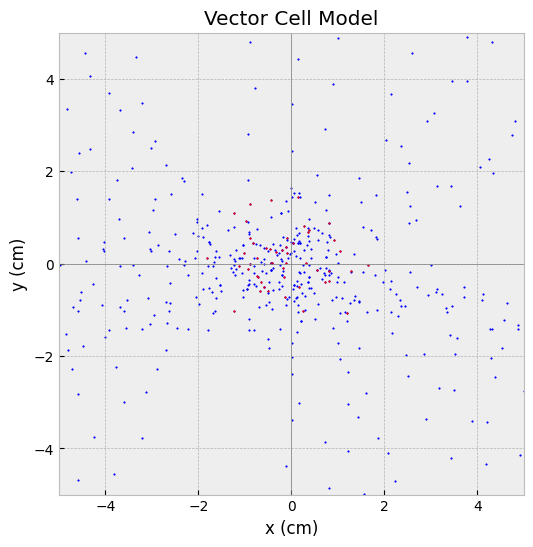

Successful trials: 50/50 (100.0%)


In [ ]:
plot_trajectories(model_name, x_histories, y_histories, hexagonal_projection=False)

### Translation vector simulation

In [5]:
def translation_vec_simulation(model_name, N=1000, arena_width = 50, gc_distortion=None, plot_results=True):

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
        title = 'DistanceCellModel'
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
        title = 'VectorCellModel'
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
        title = 'NestedModel'
    else:
        raise ValueError("Invalid model name")

    # Generate random starting positions and target positions
    a_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    b_s = [np.zeros(N) for _ in range(2)]  # Target positions are all zeros [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
  #  b_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    # Apply distortion if provided
    if gc_distortion is None or gc_distortion.distortion is None:
        print('No distortion applied.')
        a_s_dist = a_s
        b_s_dist = b_s
    else: 
        print(f'Applying {gc_distortion.distortion} distortion with a={gc_distortion.a}, b={gc_distortion.b}')
        a_s_dist = gc_distortion.apply(a_s[0], a_s[1])
        b_s_dist = gc_distortion.apply(b_s[0], b_s[1])

    # Generate translation vectors and decode them using the model
    true_trans_vecs = np.array([(b_s[0] - a_s[0]), (b_s[1] - a_s[1])])
    pred_trans_vecs = []
    for i in range(N):
        
        curr_pop_vec = model.forward(a=[a_s_dist[0][i], a_s_dist[1][i]], b=[b_s_dist[0][i], b_s_dist[1][i]])
        pred_trans_vecs.append(curr_pop_vec)
    #    print(f'b_s[0][{i}]:', b_s[0][i])
    #    true_distance = [b_s[0][i] - a_s[0][i], b_s[1][i] - a_s[1][i] ]
    #    print(f'For trial {i+1}/{N}, true distance: ({true_distance[0]}, {true_distance[1]}), decoded b_hat: ({curr_pop_vec[0]}, {curr_pop_vec[1]})')
    pred_trans_vecs = np.array(pred_trans_vecs).T




    # Plot two plots for x and y
    if plot_results:
        plt.subplots(1, 2, figsize=(12, 5))
        for i in range(2):
            plt.subplot(1, 2, i+1)
            plt.scatter(true_trans_vecs[i] / 100, pred_trans_vecs[i] / 100, color='black', s=1)
            plt.xlabel('True Translation Vector (m)')
            plt.ylabel('Decoded Translation Vector (m)')
            curr_axis = 'x' if i == 0 else 'y'
            plt.title(f'{curr_axis}-axis')
        plt.suptitle(title)
        plt.show()

    return a_s, b_s, pred_trans_vecs

In [6]:


def plot_trans_vec_results(trans_vec_results, arena_width=50):
    model_names = trans_vec_results.keys()
    for model_name in model_names:
        a_s = trans_vec_results[model_name][0]
        b_s = trans_vec_results[model_name][1]
        pred_trans_vecs = trans_vec_results[model_name][2]
        plt.figure(figsize=(8, 8))
        plt.plot(a_s[0], a_s[1], 'o', color='black', label='Start Position', markersize=1)
        plt.plot(b_s[0], b_s[1], 'o', label='End Position', markersize=1)
        for i in range(pred_trans_vecs.shape[1]):
            plt.arrow(a_s[0][i], a_s[1][i], pred_trans_vecs[0][i], pred_trans_vecs[1][i], head_width=1, head_length=1, fc='red', ec='black', alpha=0.5)
        plt.xlabel('x-axis (m)')
        plt.ylabel('y-axis (m)')
        plt.xlim(-arena_width, arena_width)
        plt.ylim(-arena_width, arena_width)
        plt.title('Translation Vectors for Distance Cell Model')
        plt.show()
plot_trans_vec_results(trans_vec_results)

NameError: name 'trans_vec_results' is not defined

Applying shear distortion with a=0.3, b=0.3


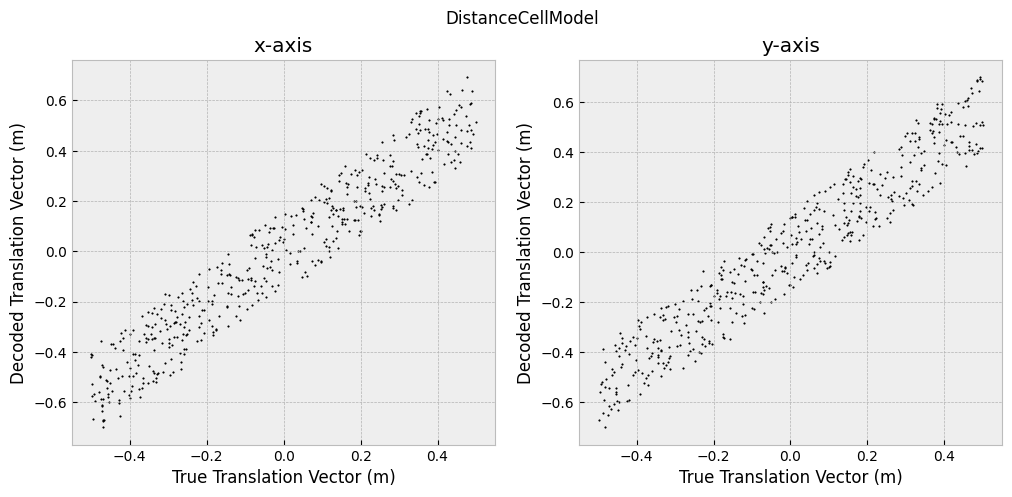

Applying shear distortion with a=0.3, b=0.3


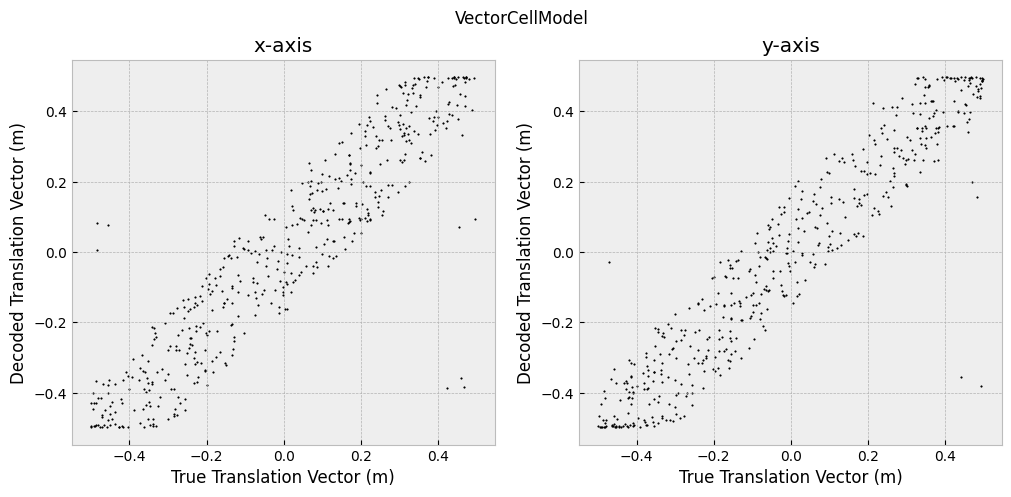

Applying shear distortion with a=0.3, b=0.3


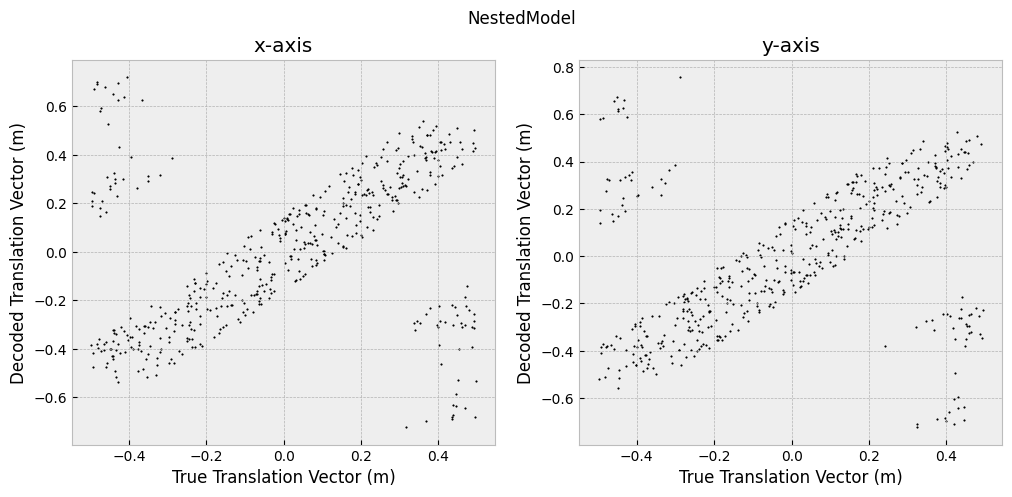

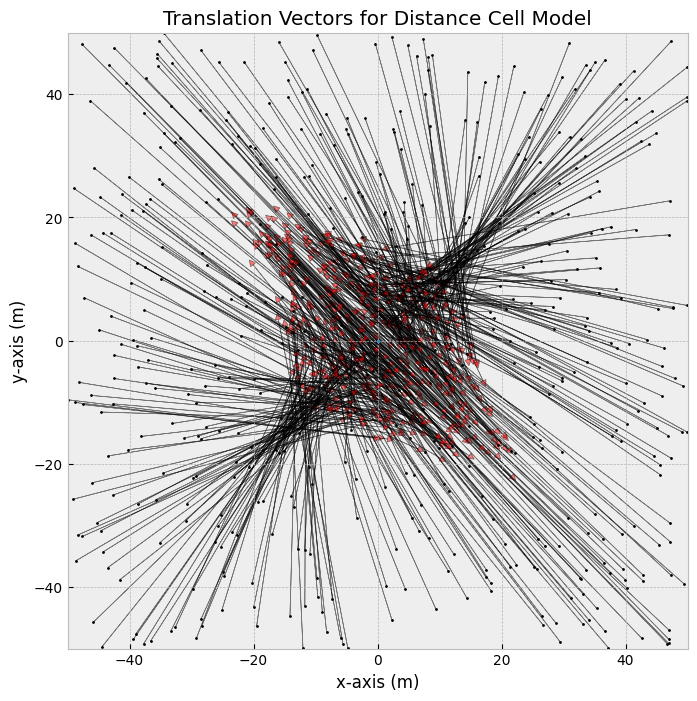

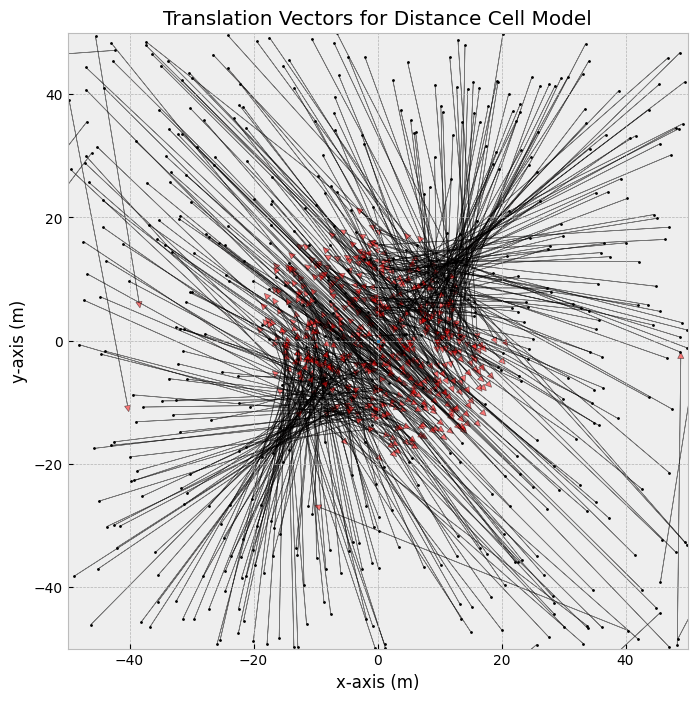

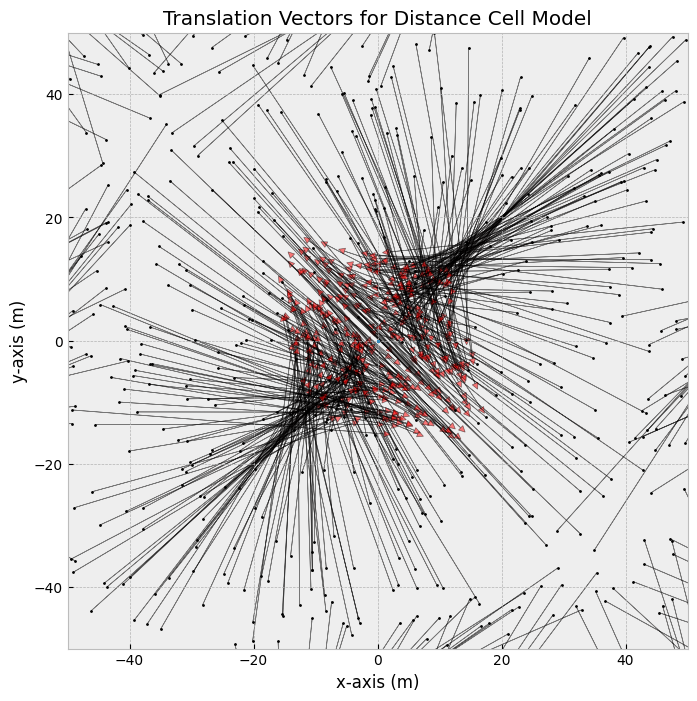

In [ ]:
trans_vec_results = {}
for model_name in ['dcm', 'vcm', 'nm']:
    a_s, b_s, pred_trans_vecs = translation_vec_simulation(model_name, 
                                                                  N=500, 
                                                                  arena_width = 50, 
                                                                  gc_distortion=GC_Distortion(distortion='shear', a=0.3, b=0.3))
    trans_vec_results[model_name] = (a_s, b_s, pred_trans_vecs)
plot_trans_vec_results(trans_vec_results)

### COMBINATORIAL (Bush et al., 2015)

In [ ]:
nm = NestedModel()
print(nm.forward(a=[250, 250], b=[258, 258]))
print(nm.forward(a=[-19, 1], b=[0, 0]))
print(nm.scales)


(-34.236222440563054, -54.79538506659507)
(18.70964991546043, -0.9138710114200769)
[100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]


In [ ]:
nm = NestedModel()
print(nm.forward(a=[250, 250], b=[258, 258]))
print(nm.forward(a=[-19, 1], b=[0, 0]))
print(nm.scales)


(-33.99893737452001, -65.14446864694553)
(19.135270365284207, -1.0637288282421462)
[100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]
